phase 3.1

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('../data/processed/cleaned_medical_notes.csv') #to load the cleaned medical notes dataset from a CSV file into a pandas DataFrame for further analysis and modeling
print(df.shape)
print(df.columns.tolist())
print(df['medical_specialty'].to_list())

(2857, 9)
['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'char_length', 'word_count', 'sentence_count', 'clean_text']
['Bariatrics', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Neurology', 'Bariatrics', 'Dentistry', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Urology', 'General Medicine', 'Urology', 'Bariatrics', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology', 'Urology

In [53]:
not_specialties = [
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.','Surgery','Radiology'
]
df = df[~df['medical_specialty'].isin(not_specialties)]
print("rows:", len(df), "| classes:", df['medical_specialty'].nunique())

rows: 2586 | classes: 26


In [54]:
X = df['clean_text']          # features (text, to be vectorized)
y = df['medical_specialty']   # labels (what we predict)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% held out for testing
    stratify=y,          # preserve class proportions in both sets
    random_state=42      # reproducible split
)
print("train:", len(X_train), "| test:", len(X_test))

train: 2068 | test: 518


In [56]:
custom_noise = ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear', 'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold'] #to create a list of noise words to remove from the text data during vectorization, these words are identified as de identified words and common words that are not informative for specialty classification


tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    stop_words=custom_noise
)

X_train_tfidf = tfidf.fit_transform(X_train)   # FIT (learn vocab + IDF) + transform
X_test_tfidf  = tfidf.transform(X_test)        # transform ONLY (reuse train's vocab)

print("train matrix:", X_train_tfidf.shape)
print("test matrix:", X_test_tfidf.shape)

train matrix: (2068, 10000)
test matrix: (518, 10000)


3.2 Model 1 Logistic Regression (the interpretable baseline)

In [57]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
logreg_preds = logreg.predict(X_test_tfidf)

3.2 Model 2 Multinomial Naive Bayes (The Text Specialist)

In [58]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

Model 3 — Random Forest (the non-linear option)

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
rf_preds = rf.predict(X_test_tfidf)

Phase 3.3
Metric 1 — Macro F1 (the honest metric)

In [60]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

for name, preds in [('Logistic Regression', logreg_preds),
                    ('Naive Bayes', nb_preds),
                    ('Random Forest', rf_preds)]:
    print(f"\n===== {name} =====")
    print("Accuracy:    ", round(accuracy_score(y_test, preds), 3))
    print("Macro F1:    ", round(f1_score(y_test, preds, average='macro'), 3))
    print("Weighted F1: ", round(f1_score(y_test, preds, average='weighted'), 3))


===== Logistic Regression =====
Accuracy:     0.703
Macro F1:     0.675
Weighted F1:  0.707

===== Naive Bayes =====
Accuracy:     0.544
Macro F1:     0.236
Weighted F1:  0.484

===== Random Forest =====
Accuracy:     0.604
Macro F1:     0.557
Weighted F1:  0.603


Metric 2 — Confusion Matrix (where the leaks are)

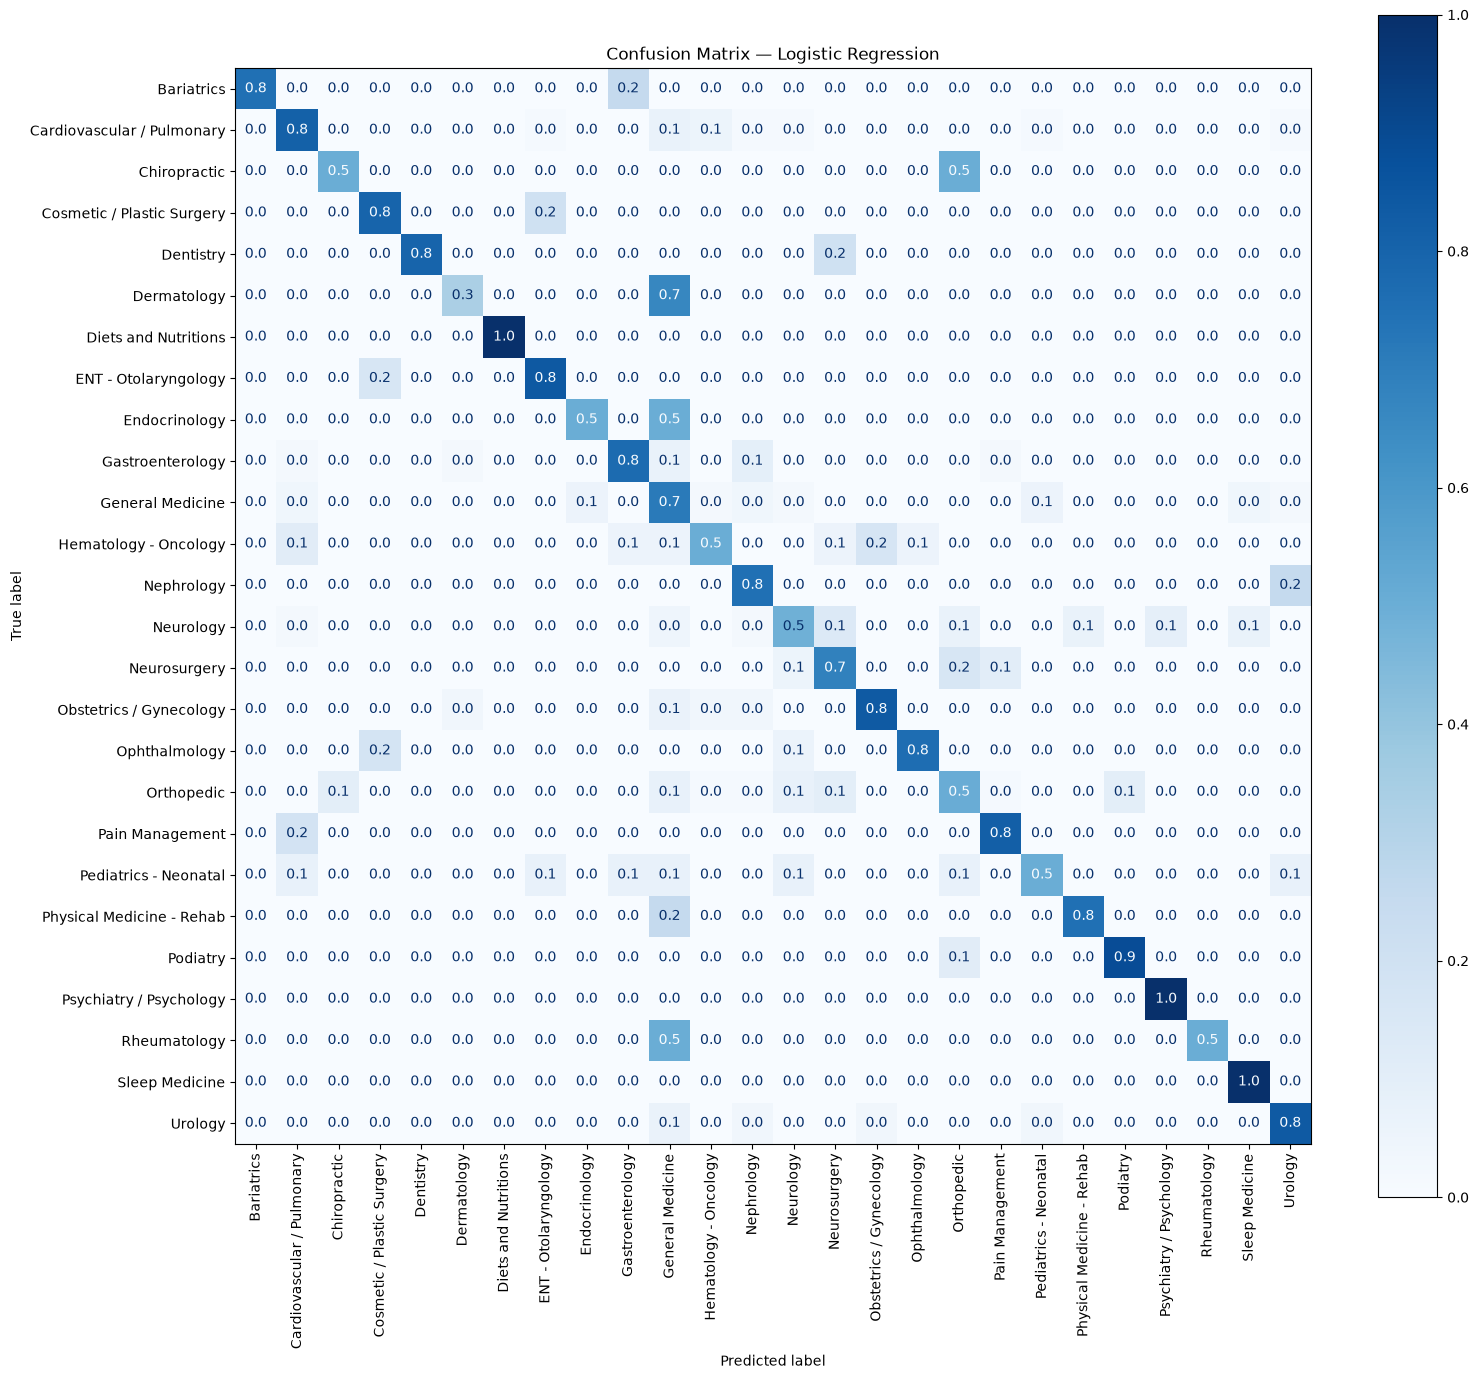

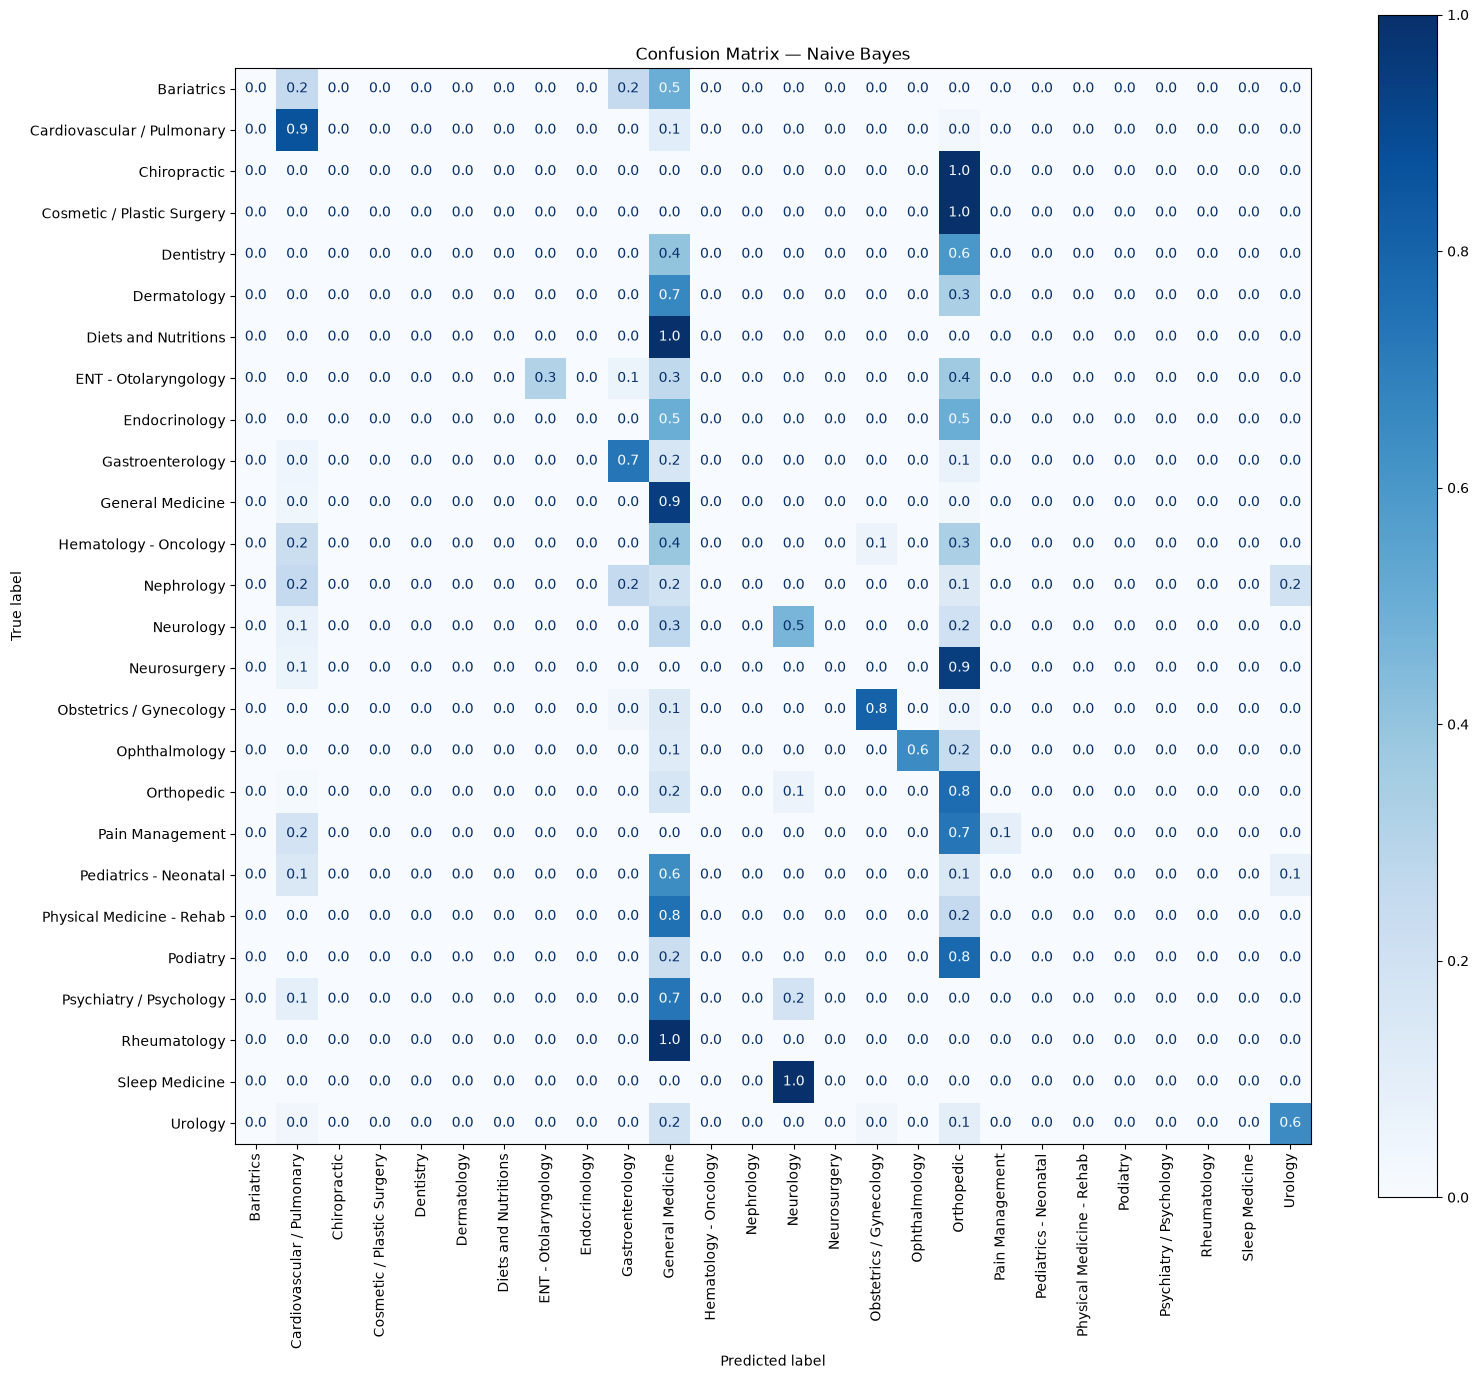

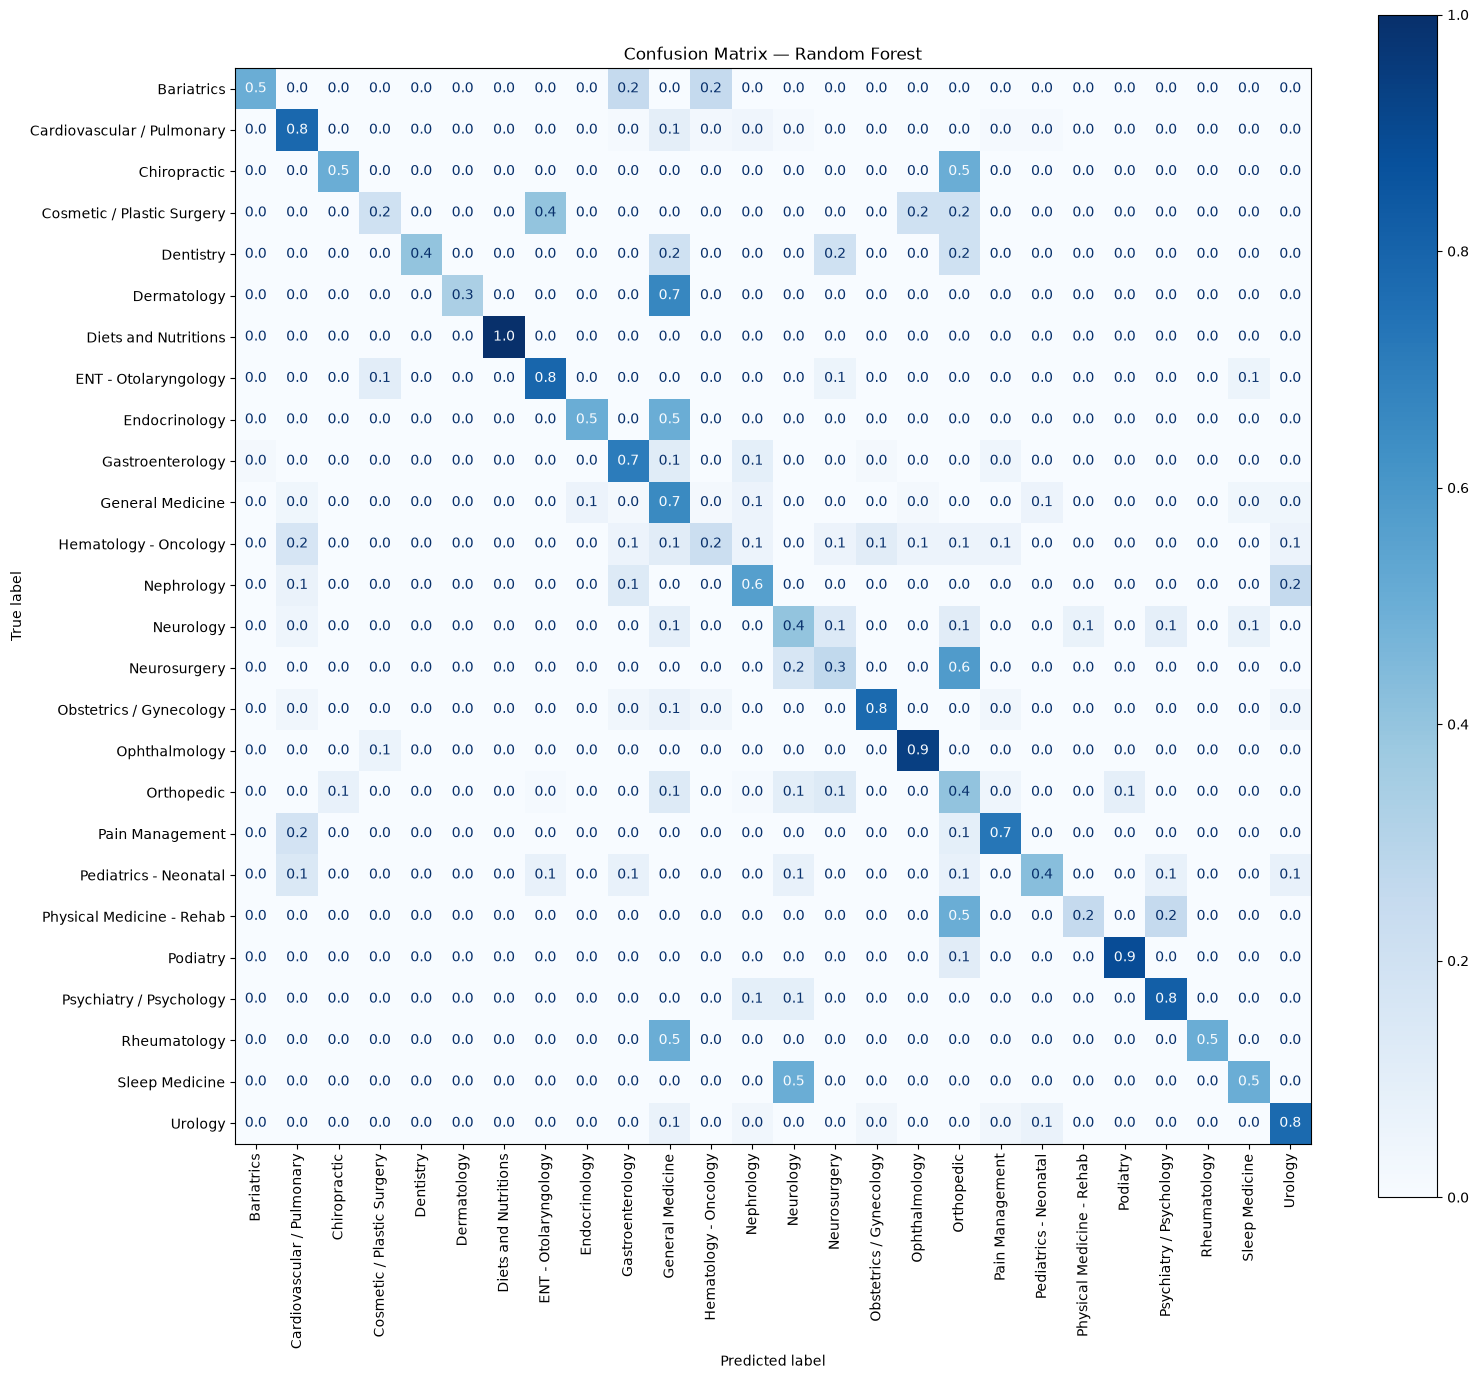

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())

models = [
    ('Logistic Regression', logreg_preds),
    ('Naive Bayes', nb_preds),
    ('Random Forest', rf_preds)
]

for name, preds in models:
    cm = confusion_matrix(y_test, preds, labels=labels, normalize='true')
    fig, ax = plt.subplots(figsize=(16, 14))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, xticks_rotation=90, cmap='Blues', values_format='.1f'
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

Metric 3: Error Analysis

In [62]:
import pandas as pd

# 1. get the model's probability for every class, per test note
probs = logreg.predict_proba(X_test_tfidf)

# 2. the model's confidence = the probability it gave its top choice
confidence = probs.max(axis=1)
predicted = logreg.classes_[probs.argmax(axis=1)]

# 3. assemble everything into one frame for inspection
results = pd.DataFrame({
    'true': y_test.values,
    'pred': predicted,
    'confidence': confidence,
    'text': X_test.values
})

# 4. keep only the WRONG ones, sorted by confidence (most confident first)
wrong = results[results['true'] != results['pred']].sort_values('confidence', ascending=False)

# 5. read the top 5 confident-but-wrong cases
for i, (_, row) in enumerate(wrong.head(5).iterrows(), 1):
    print(f"\n{'='*70}")
    print(f"CASE {i}  |  confidence: {row['confidence']:.2f}")
    print(f"TRUE: {row['true']}   →   PREDICTED: {row['pred']}")
    print(f"{'-'*70}")
    print(row['text'][:600])


CASE 1  |  confidence: 0.76
TRUE: Neurology   →   PREDICTED: Physical Medicine - Rehab
----------------------------------------------------------------------
history patient year old right handed female longstanding bilateral arm pain predominantly medial aspect arms hands well left hand numbness worse night repetitive work left hand denies weakness significant neck pain change bowel bladder symptoms change gait similar symptoms past lyrica pain somewhat successful examination reveals positive phalen test left remainder neurological examination normal nerve conduction studies left median motor distal latency prolonged normal evoked response amplitude conduction velocity left median sensory distal latency prolonged attenuated evoked response amplitu

CASE 2  |  confidence: 0.75
TRUE: Orthopedic   →   PREDICTED: Podiatry
----------------------------------------------------------------------
preoperative diagnosis foreign body right foot postoperative diagnosis foreign body right foot pr

In [63]:
import numpy as np

feature_names = tfidf.get_feature_names_out()   # the words, in column order
classes = logreg.classes_                        # the specialties, in coefficient-row order

def top_words_for(specialty, n=10):
    # find which row of the coefficient matrix is this specialty
    idx = list(classes).index(specialty)
    coefs = logreg.coef_[idx]                     # coefficients for this specialty
    top_idx = np.argsort(coefs)[-n:][::-1]        # indices of the n largest
    return [(feature_names[i], round(coefs[i], 2)) for i in top_idx]

for spec in ['Cardiovascular / Pulmonary', 'Orthopedic', 'Neurology', 'Gastroenterology']:
    print(f"\n=== {spec} ===")
    print(top_words_for(spec))


=== Cardiovascular / Pulmonary ===
[('artery', np.float64(1.74)), ('coronary', np.float64(1.74)), ('chest', np.float64(1.4)), ('atrial', np.float64(1.15)), ('heart', np.float64(1.13)), ('pulmonary', np.float64(1.11)), ('lobe', np.float64(1.02)), ('aortic', np.float64(1.02)), ('ventricular', np.float64(0.99)), ('coronary artery', np.float64(0.99))]

=== Orthopedic ===
[('fracture', np.float64(1.52)), ('knee', np.float64(1.46)), ('tendon', np.float64(1.14)), ('carpal', np.float64(1.06)), ('tourniquet', np.float64(1.03)), ('joint', np.float64(0.96)), ('ligament', np.float64(0.92)), ('tear', np.float64(0.88)), ('disc', np.float64(0.81)), ('disk', np.float64(0.81))]

=== Neurology ===
[('brain', np.float64(1.27)), ('mri', np.float64(1.17)), ('temporal', np.float64(1.06)), ('unremarkable', np.float64(1.05)), ('exam', np.float64(0.99)), ('gait', np.float64(0.94)), ('motor', np.float64(0.81)), ('weakness', np.float64(0.79)), ('tumor', np.float64(0.76)), ('revealed', np.float64(0.74))]

=== Ga